# 第 7 章 · 误差下降与线性边界代码实验

本页看两个基础学习过程：回归模型如何让误差下降，线性分类器如何把两类鸢尾花分开。重点不是公式，而是参数、误差和边界怎样随训练变化。

[章节网页](../ch7.html)

## 运行内容

- 用 Diabetes 运行 SGD 回归
- 用 Iris 运行 Perceptron
- 比较不同分类阈值

## 0. 疾病指标回归数据

先看 BMI 与疾病进展指标的关系。这个实验只用一个输入特征，方便读者把拟合直线和误差曲线对起来看。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import subprocess
import sys
import warnings
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]

def install_packages(packages):
    if not packages:
        return
    command = [sys.executable, "-m", "pip", "install", "--quiet", "--disable-pip-version-check", *packages]
    try:
        subprocess.check_call(command, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError("依赖安装失败，请检查网络后重新运行本单元。") from exc

install_packages(missing)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.datasets import load_diabetes, load_iris, load_wine
from sklearn.decomposition import PCA
from sklearn.linear_model import Perceptron, SGDRegressor
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    confusion_matrix,
    mean_squared_error,
    precision_recall_fscore_support,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 加载 Diabetes 经典回归数据集，使用 BMI 预测一年后的疾病进展指标。
diabetes = load_diabetes(as_frame=True)
gd_df = diabetes.frame[["bmi", "target"]].copy()
gd_df.columns = ["BMI", "疾病进展指标"]

X_gd = gd_df[["BMI"]].to_numpy()
y_gd = gd_df["疾病进展指标"].to_numpy()

display(gd_df.head(10))
display(gd_df.describe().round(3))

,BMI,疾病进展指标
0,0.061696,151.0
1,-0.051474,75.0
2,0.044451,141.0
3,-0.011595,206.0
4,-0.036385,135.0
5,-0.040696,97.0
6,-0.047163,138.0
7,-0.001895,63.0
8,0.061696,110.0
9,0.039062,310.0


,BMI,疾病进展指标
count,442.000,442.000
mean,-0.000,152.133
std,0.048,77.093
min,-0.090,25.000
25%,-0.034,87.000
50%,-0.007,140.500
75%,0.031,211.500
max,0.171,346.000


## 1. 误差下降

训练会重复更新斜率和截距。表格记录每一轮误差，图像显示拟合线是否逐步贴近数据趋势。

In [3]:
# 用随机梯度下降做回归，记录损失下降过程。
gd_scaler = StandardScaler()
X_gd_scaled = gd_scaler.fit_transform(X_gd)
regressor = SGDRegressor(
    loss="squared_error",
    penalty=None,
    learning_rate="invscaling",
    eta0=0.04,
    power_t=0.25,
    random_state=0,
)

gd_rows = []
for epoch in range(1, 61):
    regressor.partial_fit(X_gd_scaled, y_gd)
    pred = regressor.predict(X_gd_scaled)
    gd_rows.append({
        "轮次": epoch,
        "标准化斜率": round(regressor.coef_[0], 4),
        "截距": round(regressor.intercept_[0], 4),
        "MSE": round(mean_squared_error(y_gd, pred), 3),
    })

gd_trace = pd.DataFrame(gd_rows)
display(gd_trace.iloc[[0, 1, 2, 9, 29, 59]])

,轮次,标准化斜率,截距,MSE
0,1,46.2456,149.0037,3901.430
1,2,46.2675,150.1979,3895.430
2,3,46.1468,150.4220,3894.360
9,10,45.8489,150.9033,3892.444
29,30,45.6602,151.2201,3891.541
59,60,45.5705,151.3751,3891.200


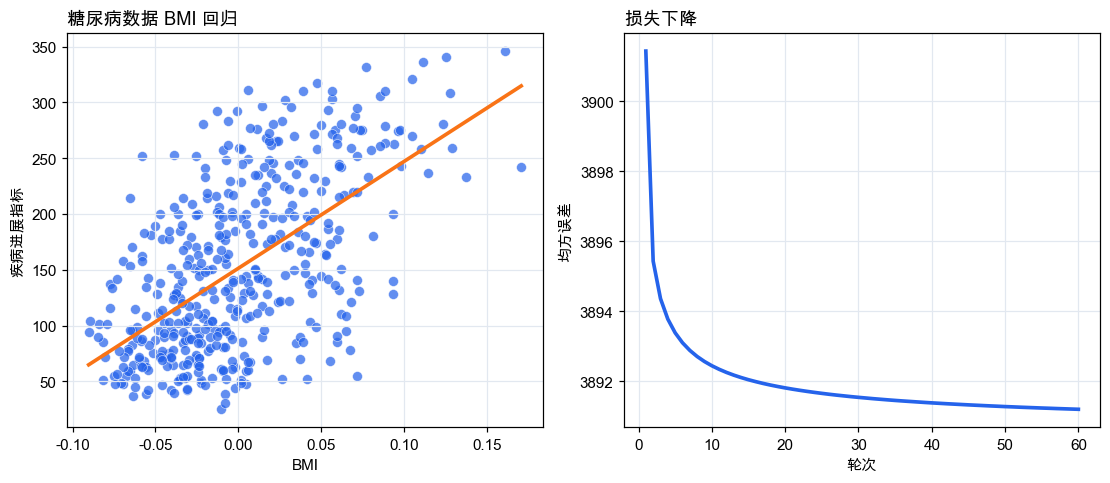

In [4]:
# 绘制拟合直线和 MSE 曲线。
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.5))

x_line = np.linspace(X_gd.min(), X_gd.max(), 100).reshape(-1, 1)
axes[0].scatter(X_gd[:, 0], y_gd, s=42, color="#2563eb", alpha=0.72, edgecolor="white", linewidth=0.4)
axes[0].plot(x_line[:, 0], regressor.predict(gd_scaler.transform(x_line)), color="#f97316", linewidth=2.4)
axes[0].set_title("糖尿病数据 BMI 回归", loc="left", fontweight="bold")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("疾病进展指标")
axes[0].grid(True, color="#e2e8f0", linewidth=0.8)

axes[1].plot(gd_trace["轮次"], gd_trace["MSE"], color="#2563eb", linewidth=2.4)
axes[1].set_title("损失下降", loc="left", fontweight="bold")
axes[1].set_xlabel("轮次")
axes[1].set_ylabel("均方误差")
axes[1].grid(True, color="#e2e8f0", linewidth=0.8)

plt.tight_layout()
plt.show()

## 2. 线性分类边界

感知机会学习一条分界线。读者可以观察错误数下降，以及最终边界如何把两类样本分开。

In [5]:
# 加载鸢尾花中的 setosa 与 versicolor，使用两个花瓣特征做感知机二分类。
iris = load_iris(as_frame=True)
perceptron_df = iris.frame.copy()
iris_feature_cn_map = dict(zip(iris.feature_names, ["萼片长度", "萼片宽度", "花瓣长度", "花瓣宽度"]))
perceptron_df["品种"] = perceptron_df["target"].map(dict(enumerate(iris.target_names)))
perceptron_df = perceptron_df[perceptron_df["品种"].isin(["setosa", "versicolor"])].copy()

per_features = ["petal length (cm)", "petal width (cm)"]
X_per = perceptron_df[per_features].to_numpy()
y_per = (perceptron_df["品种"] == "versicolor").astype(int).to_numpy()
perceptron_df["二分类标签"] = y_per

display(perceptron_df.rename(columns=iris_feature_cn_map))

,萼片长度,萼片宽度,花瓣长度,花瓣宽度,target,品种,二分类标签
0,5.1,3.5,1.4,0.2,0,setosa,0
1,4.9,3.0,1.4,0.2,0,setosa,0
2,4.7,3.2,1.3,0.2,0,setosa,0
3,4.6,3.1,1.5,0.2,0,setosa,0
4,5.0,3.6,1.4,0.2,0,setosa,0
...,...,...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,1,versicolor,1
96,5.7,2.9,4.2,1.3,1,versicolor,1
97,6.2,2.9,4.3,1.3,1,versicolor,1
98,5.1,2.5,3.0,1.1,1,versicolor,1


In [6]:
# 逐轮训练感知机，记录边界参数。
per_scaler = StandardScaler()
X_per_scaled = per_scaler.fit_transform(X_per)
perceptron = Perceptron(eta0=0.08, random_state=1, warm_start=True)
classes = np.array([0, 1])
per_rows = []

for epoch in range(1, 13):
    perceptron.partial_fit(X_per_scaled, y_per, classes=classes)
    pred = perceptron.predict(X_per_scaled)
    per_rows.append({
        "轮次": epoch,
        "花瓣长度权重": round(perceptron.coef_[0, 0], 4),
        "花瓣宽度权重": round(perceptron.coef_[0, 1], 4),
        "偏置": round(perceptron.intercept_[0], 4),
        "错误数": int((pred != y_per).sum()),
    })

per_trace = pd.DataFrame(per_rows)
display(per_trace)

,轮次,花瓣长度权重,花瓣宽度权重,偏置,错误数
0,1,0.1331,0.0569,0.0,0
1,2,0.1331,0.0569,0.0,0
2,3,0.1331,0.0569,0.0,0
3,4,0.1331,0.0569,0.0,0
4,5,0.1331,0.0569,0.0,0
5,6,0.1331,0.0569,0.0,0
6,7,0.1331,0.0569,0.0,0
7,8,0.1331,0.0569,0.0,0
8,9,0.1331,0.0569,0.0,0
9,10,0.1331,0.0569,0.0,0


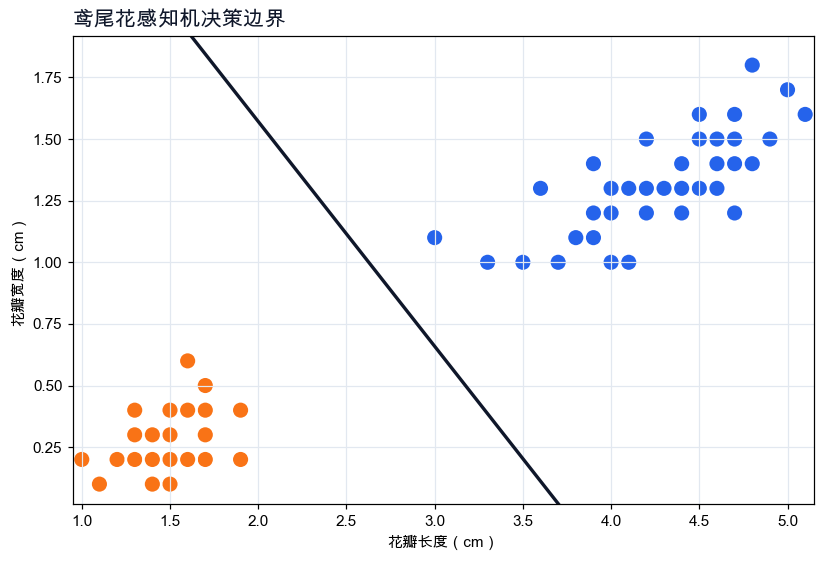

In [7]:
# 绘制感知机决策边界。
fig, ax = plt.subplots(figsize=(7.6, 5.2))
colors = np.where(y_per == 1, "#2563eb", "#f97316")
ax.scatter(X_per[:, 0], X_per[:, 1], c=colors, s=130, edgecolors="white", linewidth=1.5)

x_min, x_max = X_per[:, 0].min() - 0.05, X_per[:, 0].max() + 0.05
x_line = np.linspace(x_min, x_max, 100)
w0, w1 = perceptron.coef_[0]
bias = perceptron.intercept_[0]
scaled_x = (x_line - per_scaler.mean_[0]) / per_scaler.scale_[0]
scaled_y = -(w0 * scaled_x + bias) / w1
y_line = scaled_y * per_scaler.scale_[1] + per_scaler.mean_[1]
ax.plot(x_line, y_line, color="#0f172a", linewidth=2.2)

ax.set_title("鸢尾花感知机决策边界", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_xlabel("花瓣长度（cm）")
ax.set_ylabel("花瓣宽度（cm）")
ax.set_xlim(x_min, x_max)
ax.set_ylim(X_per[:, 1].min() - 0.08, X_per[:, 1].max() + 0.12)
ax.grid(True, color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()

## 3. 阈值指标

同一组分数，换不同阈值会改变精确率、召回率和 F1。这里用表格展示分类指标为什么依赖决策阈值。

In [8]:
# 用 Iris 感知机的 decision_function 分数观察阈值变化。
y_true = y_per
y_score = perceptron.decision_function(X_per_scaled)
thresholds = np.quantile(y_score, [0.35, 0.50, 0.65])

metric_rows = []
for threshold in thresholds:
    y_hat = (y_score >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_hat, average="binary", zero_division=0
    )
    metric_rows.append({
        "阈值": round(float(threshold), 3),
        "预测为正": int(y_hat.sum()),
        "精确率": round(precision, 3),
        "召回率": round(recall, 3),
        "F1": round(f1, 3),
    })

display(pd.DataFrame(metric_rows))

,阈值,预测为正,精确率,召回率,F1
0,-0.176,67,0.746,1.00,0.855
1,-0.042,50,1.000,1.00,1.000
2,0.157,37,1.000,0.74,0.851
